**importing libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/customer_acquisition_data.csv')
df.head()

,customer_id,channel,cost,conversion_rate,revenue
0,1,referral,8.320327,0.123145,4199
1,2,paid advertising,30.450327,0.016341,3410
2,3,email marketing,5.246263,0.043822,3164
3,4,social media,9.546326,0.167592,1520
4,5,referral,8.320327,0.123145,2419


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      800 non-null    int64  
 1   channel          800 non-null    object 
 2   cost             800 non-null    float64
 3   conversion_rate  800 non-null    float64
 4   revenue          800 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 31.4+ KB


**Pie Chart – Channel Distribution**

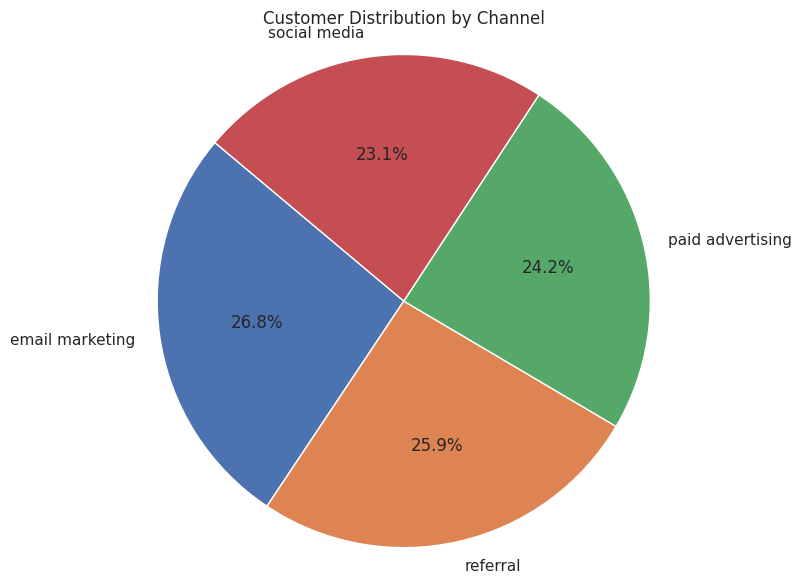

In [ ]:
# Pie chart for customer distribution by channel
channel_counts = df['channel'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(channel_counts, labels=channel_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Customer Distribution by Channel')
plt.axis('equal')
plt.show()


** CLTV Calculation**

In [ ]:
# Calculate CLTV
df['cltv'] = (df['revenue'] * df['conversion_rate']) - df['cost']

**Histogram – CLTV Distribution**

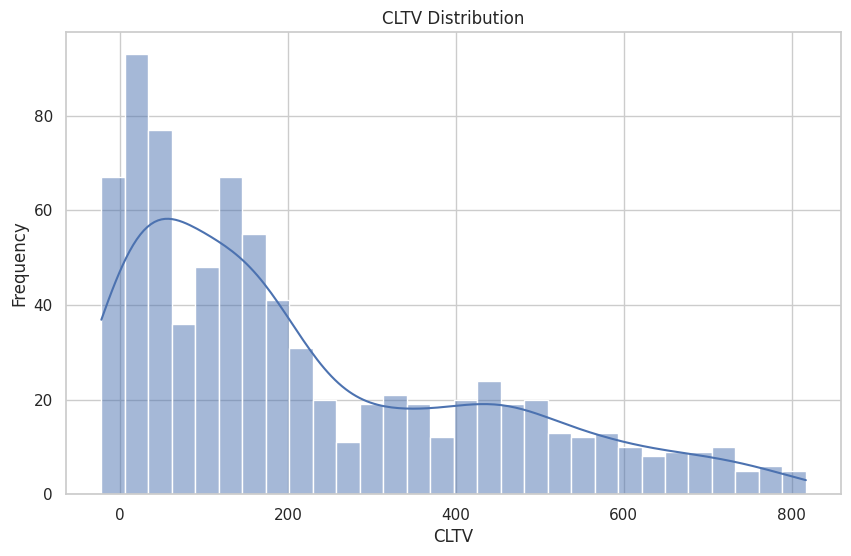

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['cltv'], bins=30, kde=True)
plt.title('CLTV Distribution')
plt.xlabel('CLTV')
plt.ylabel('Frequency')
plt.show()


**Customer Segmentation by CLTV**

<ipython-input-13-b286371c9e44>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cltv_segment', data=df, palette='Set2')


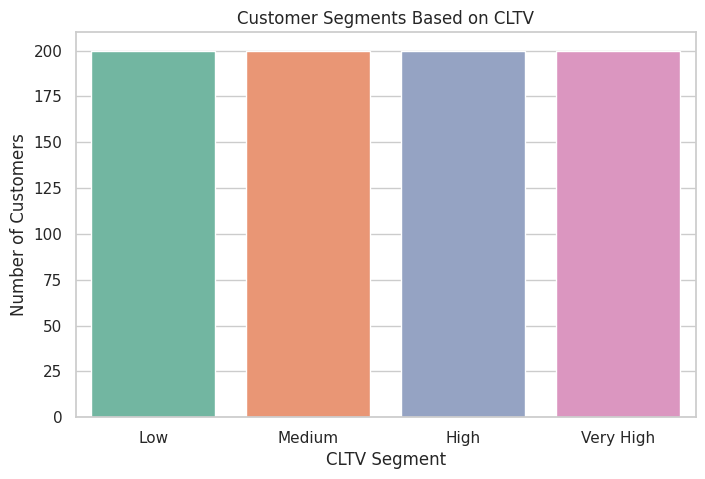

cltv_segment
Low          200
Medium       200
High         200
Very High    200
Name: count, dtype: int64


In [ ]:
df['cltv_segment'] = pd.qcut(df['cltv'], 4, labels=["Low", "Medium", "High", "Very High"])

# Countplot
plt.figure(figsize=(8, 5))
sns.countplot(x='cltv_segment', data=df, palette='Set2')
plt.title("Customer Segments Based on CLTV")
plt.xlabel("CLTV Segment")
plt.ylabel("Number of Customers")
plt.show()

# Show segment table
print(df['cltv_segment'].value_counts())


**Bar Plot – Average CLTV by Channel**

<ipython-input-14-ccec285f3d77>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_cltv.index, y=avg_cltv.values, palette="coolwarm")


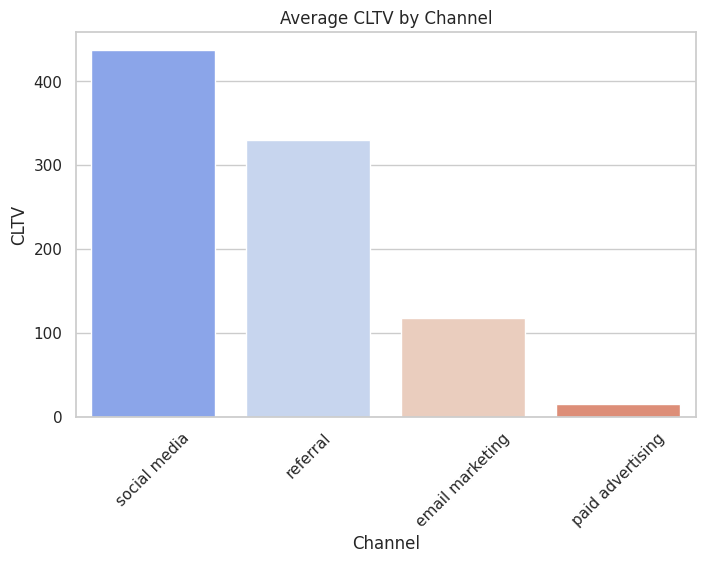

In [ ]:
plt.figure(figsize=(8, 5))
avg_cltv = df.groupby('channel')['cltv'].mean().sort_values(ascending=False)
sns.barplot(x=avg_cltv.index, y=avg_cltv.values, palette="coolwarm")
plt.title("Average CLTV by Channel")
plt.ylabel("CLTV")
plt.xlabel("Channel")
plt.xticks(rotation=45)
plt.show()


**Bar Plot – Total Revenue by Channel**

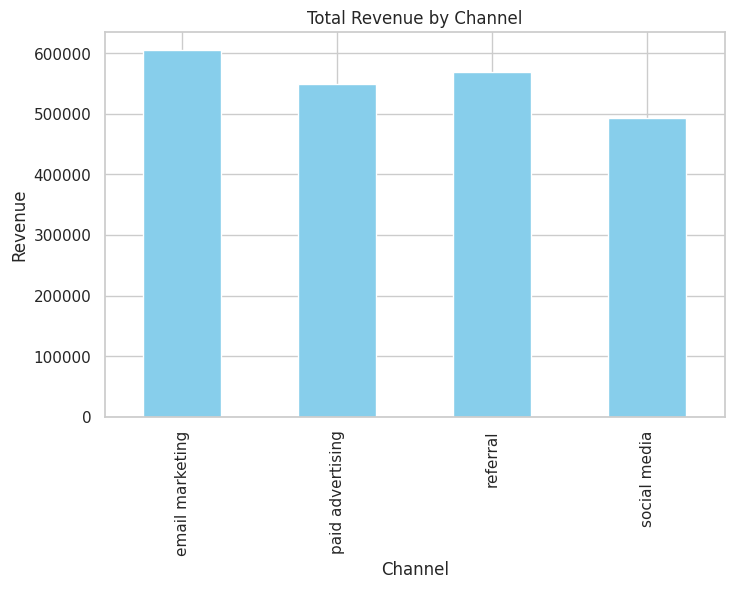

In [ ]:
plt.figure(figsize=(8, 5))
rev_by_channel = df.groupby('channel')['revenue'].sum()
rev_by_channel.plot(kind='bar', color='skyblue')
plt.title('Total Revenue by Channel')
plt.ylabel('Revenue')
plt.xlabel('Channel')
plt.show()


**Correlation Matrix & Heatmap**

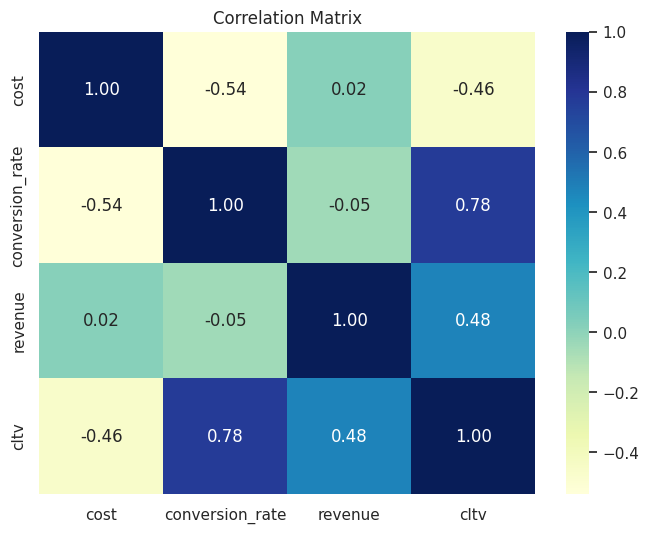

In [ ]:
# Select numeric features
numeric_df = df[['cost', 'conversion_rate', 'revenue', 'cltv']]

# Correlation matrix
corr_matrix = numeric_df.corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


In [ ]:
# Show top 10 customers by CLTV
top_customers = df.sort_values(by='cltv', ascending=False).head(10)
print(top_customers[['customer_id', 'channel', 'cost', 'conversion_rate', 'revenue', 'cltv']])


     customer_id       channel      cost  conversion_rate  revenue        cltv
552          553  social media  9.546326         0.167592     4932  817.018638
504          505  social media  9.546326         0.167592     4931  816.851046
566          567  social media  9.546326         0.167592     4866  805.957550
69            70  social media  9.546326         0.167592     4833  800.427006
707          708  social media  9.546326         0.167592     4832  800.259414
493          494  social media  9.546326         0.167592     4746  785.846480
279          280  social media  9.546326         0.167592     4720  781.489082
594          595  social media  9.546326         0.167592     4698  777.802052
322          323  social media  9.546326         0.167592     4653  770.260401
154          155  social media  9.546326         0.167592     4647  769.254848
